# Modern Parquet Paper Plot Demo

This notebook demonstrates the new analysis and paper-plotting path:

`Parquet epoch aggregates -> analysis helpers -> one curve per (agent_label, run_id) -> paper-style plot`

The example uses the checked-in smoke sweep under `results/reinforce_unified_demo`.

In [1]:
from pathlib import Path

from IPython.display import HTML
import matplotlib.pyplot as plt
import pandas as pd

from utils.analysis import (
    expand_policy_params,
    filter_epoch_rewards,
    inspect_epoch_rewards,
    last_epoch_table,
    load_epoch_rewards,
)
from utils.paper_plot import (
    AxesConfig,
    LegendConfig,
    SmoothingConfig,
    VarianceConfig,
    plot_learning_curves,
)

RESULT_ROOT = Path("results/reinforce_unified_demo")
RESULT_ROOT

PosixPath('results/reinforce_unified_demo')

## Inspect The Result Root

`inspect_epoch_rewards` gives a quick inventory of the run directory before loading or plotting.

In [2]:
inspection = inspect_epoch_rewards(RESULT_ROOT)

for key in ["rows", "columns", "epoch_min", "epoch_max", "agent_name", "agent_label", "policy_class", "run_id"]:
    if key in inspection:
        print(f"{key}: {inspection[key]}")

rows: 2400
columns: ['run_id', 'config_hash', 'setup', 'global_seed', 'num_days', 'num_trajs', 'num_epochs', 'epoch', 'agent_name', 'agent_label', 'policy_class', 'policy_params_json', 'mean_reward', 'std_reward', 'effective_learning_rate', 'grad_norm', 'n_trajs']
epoch_min: 0
epoch_max: 99
agent_name: ['baseline', 'learner']
agent_label: ['FixedBid|Bid=5|Limit=5', 'REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x4|Act=relu>relu|BaseLR=1e-6|Adaptive=False|Eps=1e-6|Eta=1e-12', 'REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x4|Act=relu>relu|BaseLR=1e-6|Adaptive=False|Eps=1e-7|Eta=1e-12', 'REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x4|Act=relu>relu|BaseLR=1e-6|Adaptive=False|Eps=1e-8|Eta=1e-12', 'REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x4|Act=relu>relu|BaseLR=1e-6|Adaptive=True|Eps=1e-6|Eta=1e-12', 'REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x4|Act=relu>relu|BaseLR=1e-6|Adaptive=True|Eps=1e-7|Eta=1e-12', 'REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x4|Act=relu>relu|BaseLR=1e-6|Adap

## Load Epoch Aggregates

The canonical analysis input is still the Parquet row schema written by the runner: one row per `(run_id, epoch, agent)`.

In [3]:
df = load_epoch_rewards(RESULT_ROOT)
if "agent_label" not in df.columns:
    raise RuntimeError(
        "This result root uses the old label schema. Regenerate configs with "
        "pipeline.make_config_grid and rerun the sweep so Parquet rows include agent_label."
    )
print(df.shape)
df.head()

(2400, 18)


,run_id,config_hash,setup,global_seed,num_days,num_trajs,num_epochs,epoch,agent_name,agent_label,policy_class,policy_params_json,mean_reward,std_reward,effective_learning_rate,grad_norm,n_trajs,source_dir
0,4f457d4d-7771-40f5-b3e1-dc681265aaa7,9db385497d5bcd07ce1d7c2a74efe67818d7801d14b200...,one_segment,123,1,100,100,0,learner,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,REINFORCE,"{""actor_final_activation"": ""relu"", ""actor_hidd...",-0.358445,0.097406,0.000001,11287.714844,100,results/reinforce_unified_demo
1,4f457d4d-7771-40f5-b3e1-dc681265aaa7,9db385497d5bcd07ce1d7c2a74efe67818d7801d14b200...,one_segment,123,1,100,100,0,baseline,FixedBid|Bid=5|Limit=5,FixedBidPolicy,"{""bid_per_item"": 5, ""total_limit"": 5}",0.000000,0.000000,NaN,NaN,100,results/reinforce_unified_demo
2,4f457d4d-7771-40f5-b3e1-dc681265aaa7,9db385497d5bcd07ce1d7c2a74efe67818d7801d14b200...,one_segment,123,1,100,100,1,learner,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,REINFORCE,"{""actor_final_activation"": ""relu"", ""actor_hidd...",0.901496,0.307972,0.000001,14213.977539,100,results/reinforce_unified_demo
3,4f457d4d-7771-40f5-b3e1-dc681265aaa7,9db385497d5bcd07ce1d7c2a74efe67818d7801d14b200...,one_segment,123,1,100,100,1,baseline,FixedBid|Bid=5|Limit=5,FixedBidPolicy,"{""bid_per_item"": 5, ""total_limit"": 5}",0.000000,0.000000,NaN,NaN,100,results/reinforce_unified_demo
4,4f457d4d-7771-40f5-b3e1-dc681265aaa7,9db385497d5bcd07ce1d7c2a74efe67818d7801d14b200...,one_segment,123,1,100,100,2,learner,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,REINFORCE,"{""actor_final_activation"": ""relu"", ""actor_hidd...",2.303680,0.658232,0.000001,15132.278320,100,results/reinforce_unified_demo


## Expand Policy Params Quietly

`policy_params_json` is preserved in the Parquet output. `expand_policy_params` turns selected JSON fields into regular DataFrame columns without warning on baseline rows that do not have learner-only params.

Important: `agent_label` is per-agent metadata and is the default curve label for plotting. `agent_name` identifies the agent slot and `policy_class` identifies the policy implementation.

In [4]:
expanded = expand_policy_params(
    df,
    fields=(
        "learning_rate",
        "use_baseline",
        "dist_type",
        "actor_hidden_layers",
        "actor_hidden_units",
        "critic_hidden_layers",
        "critic_hidden_units",
    ),
)

expanded[[
    "agent_name",
    "policy_class",
    "agent_label",
    "run_id",
    "epoch",
    "mean_reward",
    "std_reward",
    "param_learning_rate",
    "param_use_baseline",
    "param_dist_type",
]].head()

,agent_name,policy_class,agent_label,run_id,epoch,mean_reward,std_reward,param_learning_rate,param_use_baseline,param_dist_type
0,learner,REINFORCE,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,4f457d4d-7771-40f5-b3e1-dc681265aaa7,0,-0.358445,0.097406,0.000001,True,gaussian
1,baseline,FixedBidPolicy,FixedBid|Bid=5|Limit=5,4f457d4d-7771-40f5-b3e1-dc681265aaa7,0,0.000000,0.000000,<NA>,<NA>,<NA>
2,learner,REINFORCE,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,4f457d4d-7771-40f5-b3e1-dc681265aaa7,1,0.901496,0.307972,0.000001,True,gaussian
3,baseline,FixedBidPolicy,FixedBid|Bid=5|Limit=5,4f457d4d-7771-40f5-b3e1-dc681265aaa7,1,0.000000,0.000000,<NA>,<NA>,<NA>
4,learner,REINFORCE,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,4f457d4d-7771-40f5-b3e1-dc681265aaa7,2,2.303680,0.658232,0.000001,True,gaussian


## Focus On Learner Rows

The plotting API defaults to `agent_name="learner"`, but filtering explicitly makes tables easier to read.

In [5]:
learner = filter_epoch_rewards(expanded, agent_name="learner")
print(learner.shape)
learner[["policy_class", "agent_label", "run_id", "epoch", "mean_reward", "std_reward"]].head()

(1200, 25)


,policy_class,agent_label,run_id,epoch,mean_reward,std_reward
0,REINFORCE,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,4f457d4d-7771-40f5-b3e1-dc681265aaa7,0,-0.358445,0.097406
2,REINFORCE,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,4f457d4d-7771-40f5-b3e1-dc681265aaa7,1,0.901496,0.307972
4,REINFORCE,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,4f457d4d-7771-40f5-b3e1-dc681265aaa7,2,2.303680,0.658232
6,REINFORCE,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,4f457d4d-7771-40f5-b3e1-dc681265aaa7,3,2.929820,1.416889
8,REINFORCE,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,4f457d4d-7771-40f5-b3e1-dc681265aaa7,4,3.550877,0.145558


## Final-Epoch Table

This keeps `(agent_label, run_id, agent_name)` distinct. There is no cross-run aggregation by default.

In [6]:
last_epoch_table(
    learner,
    include_cols=(
        "policy_class",
        "param_learning_rate",
        "param_use_baseline",
        "param_dist_type",
    ),
)

,agent_label,run_id,agent_name,last_epoch,last_epoch_mean_reward,policy_class,param_learning_rate,param_use_baseline,param_dist_type
0,REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x...,e6efb0e6-c3e8-4a52-8654-5188ef5b00e3,learner,99,2.763904,REINFORCE,0.000001,False,gaussian
1,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,2cd72bca-9615-4c39-b9d3-077c2fc8d159,learner,99,2.714151,REINFORCE,0.000001,True,gaussian
2,REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x...,296fb569-c88b-4bb5-8451-c2e9698faca7,learner,99,1.725938,REINFORCE,0.000001,False,gaussian
3,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,13163119-4e71-42dd-b1b6-7cebbc82023e,learner,99,1.709752,REINFORCE,0.000001,True,gaussian
4,REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x...,c9b985af-56fc-4972-b6d5-5d6760a57d94,learner,99,0.635206,REINFORCE,0.000001,False,gaussian
5,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,afb0ef8e-3c67-4fe2-a635-97dfce9e32e0,learner,99,0.629339,REINFORCE,0.000001,True,gaussian
6,REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x...,9d2ae80e-fb20-45e0-a5da-486bb85f2205,learner,99,0.000000,REINFORCE,0.000001,False,gaussian
7,REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x...,1ce415db-acf8-4a55-8c52-91ca82b1df3a,learner,99,0.000000,REINFORCE,0.000001,False,gaussian
8,REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x...,768dd688-9335-4c21-b5f6-e53636dc889a,learner,99,0.000000,REINFORCE,0.000001,False,gaussian
9,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4...,4f457d4d-7771-40f5-b3e1-dc681265aaa7,learner,99,0.000000,REINFORCE,0.000001,True,gaussian


## Run Picker

Use this compact table to choose a run. The `choice` index is a short handle for selecting the curve below.

In [7]:
run_picker = (
    learner[["agent_label", "run_id"]]
    .drop_duplicates()
    .sort_values(["agent_label", "run_id"])
    .reset_index(drop=True)
    .rename_axis("choice")
)

run_picker[["agent_label"]].style.set_properties(
    subset=["agent_label"],
    **{"white-space": "normal", "text-align": "left", "min-width": "520px"},
)

,agent_label
choice,
0,REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x4|Act=relu>relu|BaseLR=1e-6|Adaptive=False|Eps=1e-6|Eta=1e-12
1,REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x4|Act=relu>relu|BaseLR=1e-6|Adaptive=False|Eps=1e-7|Eta=1e-12
2,REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x4|Act=relu>relu|BaseLR=1e-6|Adaptive=False|Eps=1e-8|Eta=1e-12
3,REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x4|Act=relu>relu|BaseLR=1e-6|Adaptive=True|Eps=1e-6|Eta=1e-12
4,REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x4|Act=relu>relu|BaseLR=1e-6|Adaptive=True|Eps=1e-7|Eta=1e-12
5,REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x4|Act=relu>relu|BaseLR=1e-6|Adaptive=True|Eps=1e-8|Eta=1e-12
6,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4|Act=relu>relu|BaseLR=1e-6|Adaptive=False|Eps=1e-6|Eta=1e-12
7,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4|Act=relu>relu|BaseLR=1e-6|Adaptive=False|Eps=1e-7|Eta=1e-12
8,REINFORCE|Baseline=True|D=gaussian|A=4x4|C=4x4|Act=relu>relu|BaseLR=1e-6|Adaptive=False|Eps=1e-8|Eta=1e-12


## Selected Run Epoch Table

Set `SELECTED_CHOICE` to one of the index values above to inspect the tabular version of that curve.

In [8]:
SELECTED_CHOICE = 1
selected_run = run_picker.loc[SELECTED_CHOICE]
SELECTED_RUN_ID = selected_run["run_id"]

selected_curve = (
    learner[learner["run_id"] == SELECTED_RUN_ID]
    .sort_values("epoch")
    .loc[:, ["epoch", "mean_reward", "std_reward"]]
    .reset_index(drop=True)
)

print(selected_run["agent_label"])
HTML(
    '<div style="max-height: 420px; overflow-y: auto; border: 1px solid #ddd;">'
    + selected_curve.to_html(index=False)
    + "</div>"
)

REINFORCE|Baseline=False|D=gaussian|A=4x4|C=4x4|Act=relu>relu|BaseLR=1e-6|Adaptive=False|Eps=1e-7|Eta=1e-12


epoch,mean_reward,std_reward
0,-0.358445,0.097406
1,0.908092,0.312202
2,2.297903,0.660567
3,2.966544,1.398221
4,3.602296,0.166891
5,0.912844,1.672902
6,0.574090,1.374020
7,0.809823,1.588593
8,0.638458,1.629556
9,0.832725,1.632836


## Paper-Style Learning Curves

The default curve identity is one line per `(agent_label, run_id)`. Color is keyed by `agent_label`, so repeated runs of the same learner configuration can share a color while remaining separate curves.

In [15]:
subset = learner[
    learner["agent_label"].str.contains("Adaptive=True", regex=False, na=False)
    & learner["agent_label"].str.contains("Baseline=False", regex=False, na=False)
]

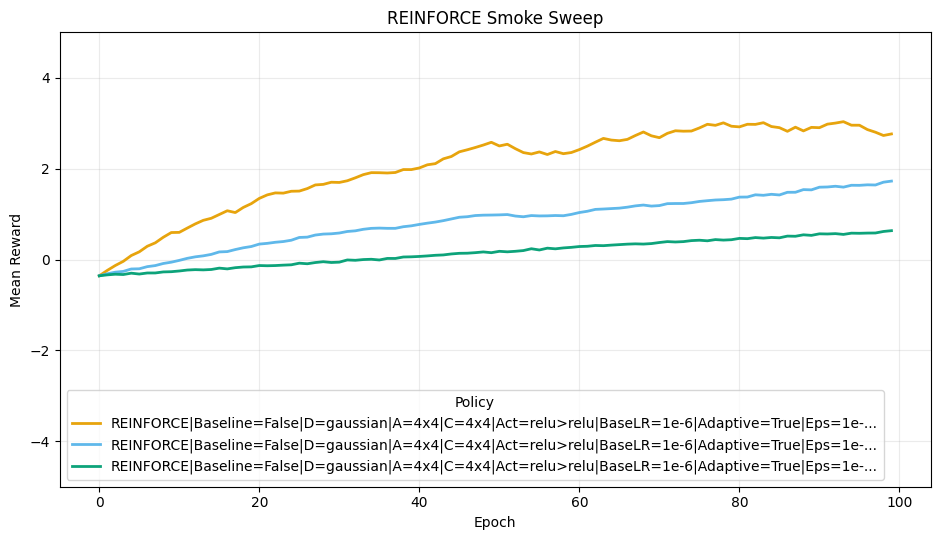

In [16]:
fig, ax = plot_learning_curves(
    subset,
    axes=AxesConfig(ylim=(-5, 5)),
    legend=LegendConfig(loc="best", max_label_chars=96),
    title="REINFORCE Smoke Sweep",
    figsize=(10, 5.5),
)
plt.show()

## Optional Smoothing And Trajectory Variance Band

`std_reward` is the per-epoch trajectory-level standard deviation written by the runner. The band below is not a cross-run confidence interval; it visualizes rollout reward variance for each displayed curve.

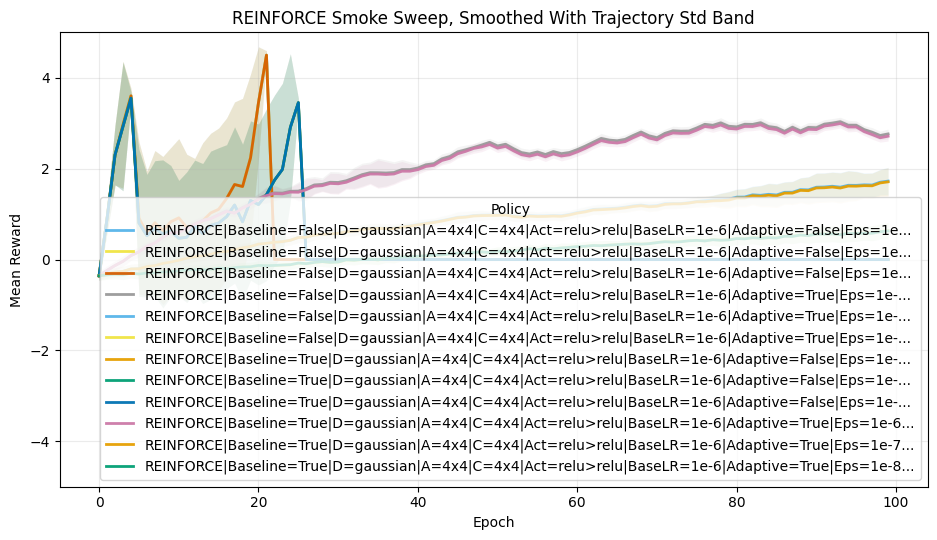

In [10]:
fig, ax = plot_learning_curves(
    learner,
    # The rolling mean is trailing: epoch t averages up to the previous 4 epochs plus t.
    # smoothing=SmoothingConfig(window=5),
    variance=VarianceConfig(column="std_reward", alpha=0.10),
    axes=AxesConfig(ylim=(-5, 5)),
    legend=LegendConfig(loc="best", max_label_chars=96),
    title="REINFORCE Smoke Sweep, Smoothed With Trajectory Std Band",
    figsize=(10, 5.5),
)
plt.show()

## CLI Inspection Equivalent

For quick smoke-test debugging outside a notebook, run:

```bash
make run ARGS="python -m utils.analysis results/reinforce_unified_demo"
```